# CosmicLarge Reference vs Target VAE Latents

Loads the local CosmicLarge sample, prepares refs through `CosmicLargeTrain`, encodes refs with the existing `PhotomakerBranchedLora._encode_reference_latent()`, and decodes target/ref latents for visual comparison.

In [10]:
from pathlib import Path
from types import ModuleType, SimpleNamespace
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import AutoencoderKL
from torchvision import transforms

PROJECT = Path('/home/kolyangg/rsrch/diffusion_template')
sys.path.insert(0, str(PROJECT))

# Allows importing src.datasets.cosmic in a lightweight local kernel where hydra is not installed.
# In the training env this block is a no-op.
try:
    import hydra  # noqa: F401
except ModuleNotFoundError:
    hydra = ModuleType('hydra')
    hydra_utils = ModuleType('hydra.utils')
    hydra_utils.instantiate = lambda *args, **kwargs: None
    hydra.utils = hydra_utils
    sys.modules['hydra'] = hydra
    sys.modules['hydra.utils'] = hydra_utils

from src.datasets.cosmic import CosmicLargeTrain
from src.model.photomaker_branched.lora2 import PhotomakerBranchedLora

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.bfloat16 if device.type == 'cuda' else torch.float32
torch.set_grad_enabled(False)

DATA_JSON = Path('/home/kolyangg/rsrch/dataset_full/cosmic_large/gathered_data_cosmic_large_filtered_sample_two.json')
REF_ROOT = Path('/home/kolyangg/rsrch/dataset_full/cosmic_large/LAION-5B-Filtered-Large-Faces')
TARGET_ROOT = Path('/home/kolyangg/rsrch/dataset_full/LAION-5B-Filtered-Large')
MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'
TARGET_SIZE = 1024
INDEX = 0
random.seed(0)
np.random.seed(0)

In [11]:
ds = CosmicLargeTrain(
    data_json_pth=str(DATA_JSON),
    images_path=str(REF_ROOT),
    target_images_path=str(TARGET_ROOT),
    path_prefix_to_strip='LAION-5B-Filtered-Large',
    num_refs=1,
    min_face_res=1,
    target_crop_256=False,  # matches start_ba_cosm_new1.sh
    instance_transforms=None,  # keep PILs visible; target tensor transform below matches training transform
)

item = ds[INDEX]
target_pil = item['pixel_values']
ref_pil = item['ref_images'][0]

print('target PIL size:', target_pil.size, 'target bbox:', item['face_bbox'])
print('ref PIL size after CosmicLargeTrain.get_ref_images:', ref_pil.size, 'ref bbox:', item['face_bbox_ref'])
print('prompt:', item['prompt'])

target PIL size: (1024, 1024) target bbox: [744, 73, 829, 188]
ref PIL size after CosmicLargeTrain.get_ref_images: (256, 244) ref bbox: [55.0, 38.0, 196.0, 231.0]
prompt: The woman img has light brown styled hair with soft waves, makeup accentuates blue eyes and pink lips, wears delicate earrings and a headpiece, serene expression with slight smile, youthful and radiant, stands with back slightly turned, sleeveless intricately beaded gown with sheer back adorned with cascading pearls, left hand rests on hip, right arm bent, mermaid-style skirt, gazes over shoulder, dark textured backdrop, black curtain drapes left, emphasizes attire


In [12]:
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder='vae').to(device=device, dtype=dtype).eval()

to_train_tensor = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

target_tensor = to_train_tensor(target_pil).unsqueeze(0).to(device=device, dtype=dtype)
target_latent = vae.encode(target_tensor).latent_dist.mode() * vae.config.scaling_factor

# Reuse the exact reference-latent helper used by PhotomakerBranchedLora.forward().
ref_encoder = SimpleNamespace(target_size=TARGET_SIZE, device=device, vae=vae)
ref_latent = PhotomakerBranchedLora._encode_reference_latent(
    ref_encoder,
    ref_pil,
    target_shape=tuple(target_latent.shape[-2:]),
)

print('target_tensor:', tuple(target_tensor.shape))
print('target_latent:', tuple(target_latent.shape), 'mean/std:', float(target_latent.mean()), float(target_latent.std()))
print('ref_latent:', tuple(ref_latent.shape), 'mean/std:', float(ref_latent.mean()), float(ref_latent.std()))

target_tensor: (1, 3, 1024, 1024)
target_latent: (1, 4, 128, 128) mean/std: -0.07666015625 0.92578125
ref_latent: (1, 4, 128, 128) mean/std: -0.2578125 0.7890625


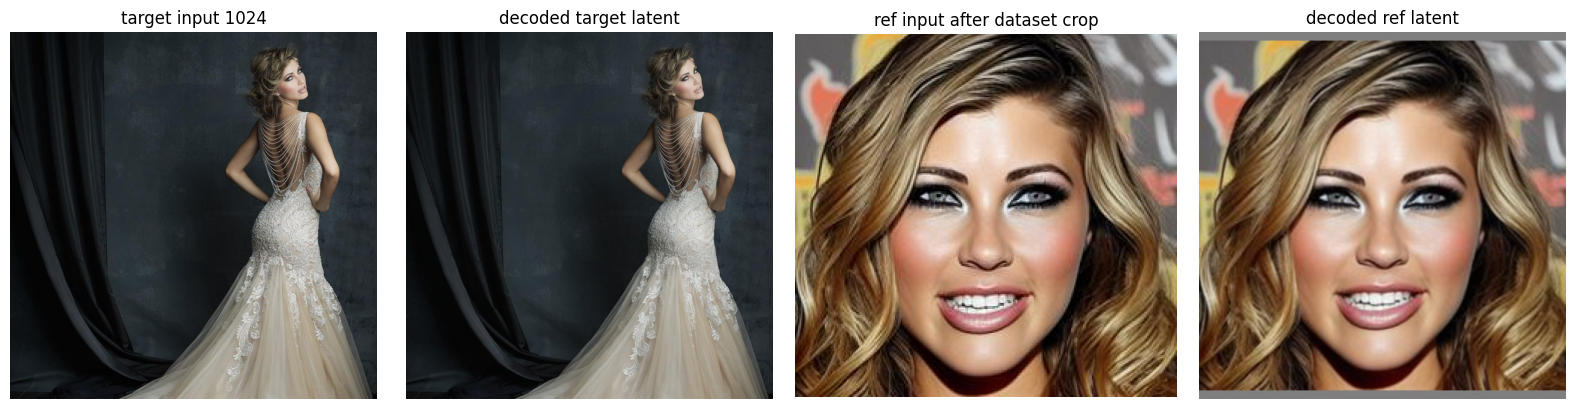

In [13]:
def decode_latent(latent):
    x = (latent / vae.config.scaling_factor).to(device=device, dtype=dtype)
    img = vae.decode(x, return_dict=False)[0]
    img = (img / 2 + 0.5).clamp(0, 1)[0].float().cpu().permute(1, 2, 0).numpy()
    return img

target_decoded = decode_latent(target_latent)
ref_decoded = decode_latent(ref_latent)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(target_pil); axes[0].set_title('target input 1024')
axes[1].imshow(target_decoded); axes[1].set_title('decoded target latent')
axes[2].imshow(ref_pil); axes[2].set_title('ref input after dataset crop')
axes[3].imshow(ref_decoded); axes[3].set_title('decoded ref latent')
for ax in axes:
    ax.axis('off')
plt.tight_layout()